In [1]:
import pandas as pd
import duckdb
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

db_path = '../database/financial_data.duckdb'

conn = duckdb.connect(db_path, read_only=True)
df = conn.execute("select * from gold_ml_features where asset_symbol = 'BTC' and interval = '1h'").df()

print(f"analyzing btc 1h: {len(df)} candles")

analyzing btc 1h: 52755 candles


rsi_14       | skew:   0.03 | kurtosis:   0.10
atr_14       | skew:   1.12 | kurtosis:   2.18
log_returns  | skew:  -0.32 | kurtosis:  17.59


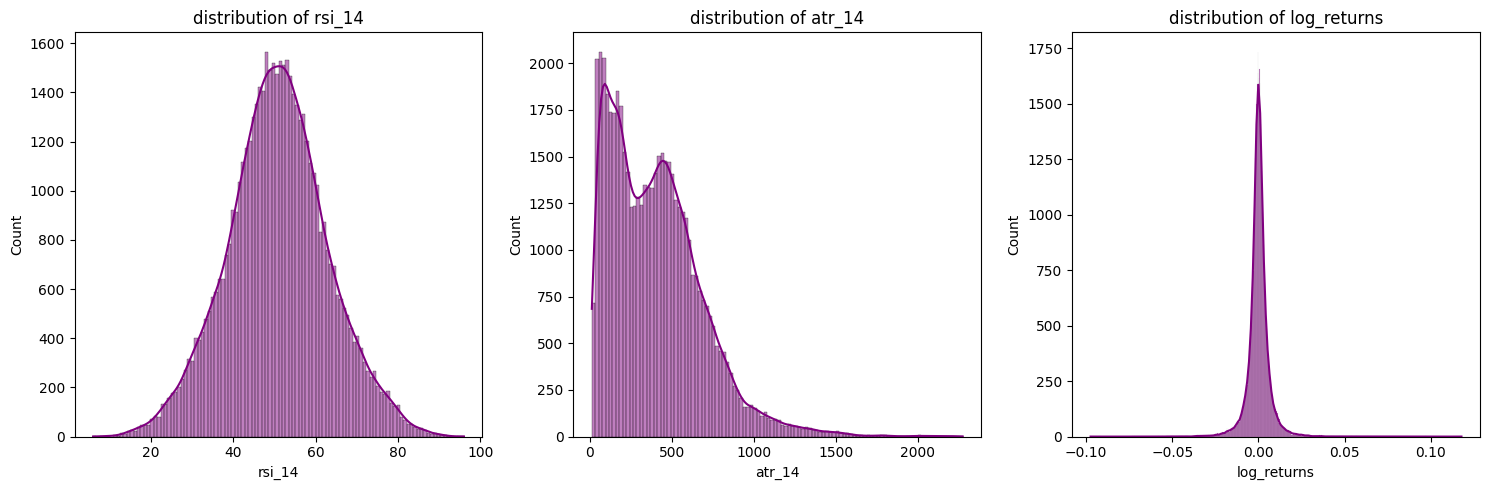

In [2]:
features_to_check = ['rsi_14', 'atr_14', 'log_returns']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, color='purple')
    plt.title(f'distribution of {col}')
    
    s = skew(df[col].dropna())
    k = kurtosis(df[col].dropna())
    print(f"{col:12} | skew: {s:6.2f} | kurtosis: {k:6.2f}")

plt.tight_layout()
plt.show()

In [3]:
col = 'log_returns'
k_orig = kurtosis(df[col].dropna())
print(f"original kurtosis: {k_orig:.2f}")

original kurtosis: 17.59


In [4]:
lower_limit = df[col].quantile(0.01)
upper_limit = df[col].quantile(0.99)

df_cured = df.copy()
df_cured[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

k_new = kurtosis(df_cured[col].dropna())
print(f"new kurtosis after 'cure': {k_new:.2f}")

new kurtosis after 'cure': 2.77


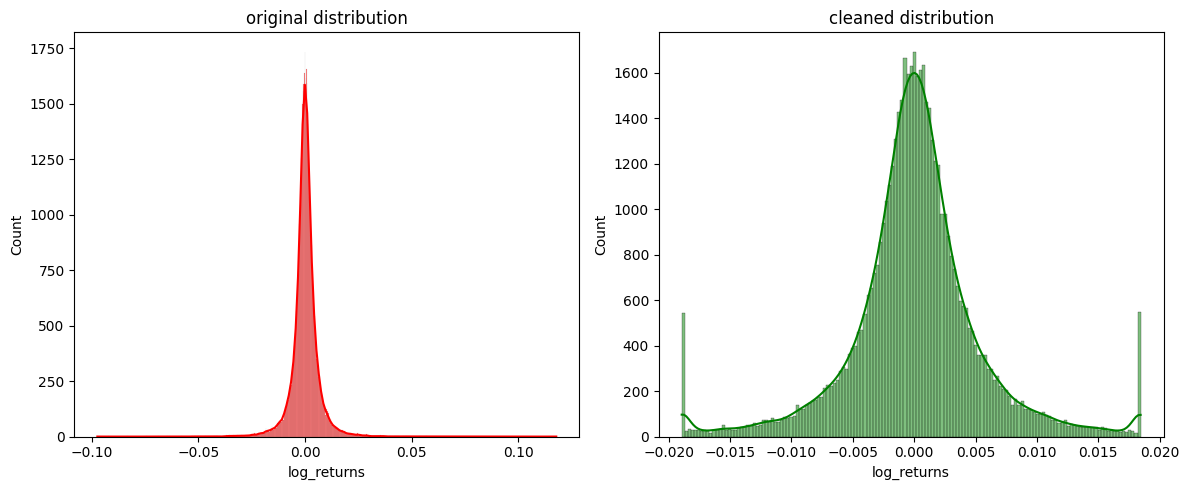

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, color='red')
plt.title('original distribution')

plt.subplot(1, 2, 2)
sns.histplot(df_cured[col], kde=True, color='green')
plt.title('cleaned distribution')

plt.tight_layout()
plt.show()


In [6]:
features = ['open', 'high', 'low', 'close', 'volume', 'rsi_14', 'atr_14', 'log_returns']

corr_matrix = df_cured[features].corr()

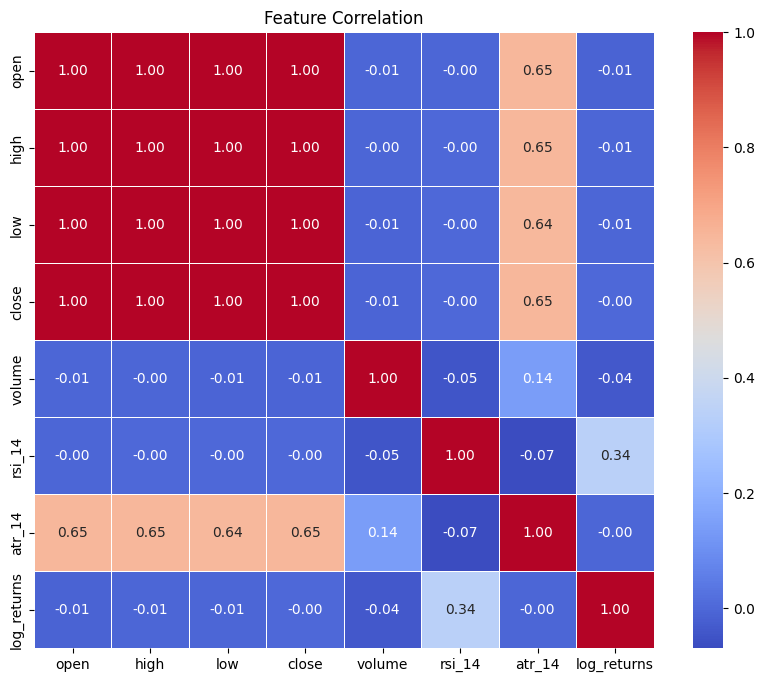

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation')
plt.show()

In [8]:
conn.close()